# 02. Comparison Analysis: Comparing Performance Across Categories
### Primary Analytical Purpose: *How do categories differ?*

---

## 1. Learning Objectives

By completing this notebook, you will be able to:
- **Compare Discrete Groups**: Identify performance disparities across distinct product lines and geographic regions.
- **Analyze Multidimensional Categories**: Use grouped bar charts to evaluate interaction effects between categories and regions.
- **Master Bar Chart Standards**: Create publication-ready static charts in **Seaborn** and interactive web charts in **Plotly Express**.
- **Avoid Baseline Truncation**: Understand why starting the numerical axis at zero is essential for ethical data visualization.

**The Analytical Workflow:**
$$\text{Business Question} \longrightarrow \text{Analyze Data} \longrightarrow \text{Visualize Patterns} \longrightarrow \text{Interpret Visuals} \longrightarrow \text{Actionable Insight}$$


## 2. Business Scenario

**Company:** *Nova Retail Group* — a multinational consumer goods distributor.  
**Context:** Nova operates four major product categories: **Electronics**, **Furniture**, **Apparel**, and **Home & Kitchen** across three key geographic operating regions: **North America**, **Europe**, and **Asia-Pacific**.

The Chief Operating Officer (COO) has noticed that although overall sales revenue appears healthy, regional profit margins vary wildly. Management needs to identify which product categories and regions generate high-volume revenue, and crucially, which combinations are draining company profitability.


In [1]:
# Standard imports for data analysis and visualization
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

# Set modern Seaborn visual theme
sns.set_theme(style="whitegrid")


## 3. Dataset Creation

We generate a structured dataset containing annual sales revenue and net profit across all category-region combinations.
The dataset reflects realistic commercial trade-offs:
- **Electronics**: High sales volume across all regions, but moderate profit margins.
- **Furniture**: Substantial sales, but severe logistics costs in Europe resulting in net losses.
- **Apparel**: Moderate sales volume with exceptionally high profit margins.
- **Home & Kitchen**: Consistent, stable performance across all three territories.


In [2]:
# Define categorical dimensions
categories = ["Electronics", "Furniture", "Apparel", "Home & Kitchen"]
regions = ["North America", "Europe", "Asia-Pacific"]

# Build realistic sales and profit figures ($ thousands)
records = [
    # Electronics
    {"category": "Electronics", "region": "North America", "sales": 420000, "profit": 58000},
    {"category": "Electronics", "region": "Europe",        "sales": 340000, "profit": 41000},
    {"category": "Electronics", "region": "Asia-Pacific",  "sales": 390000, "profit": 52000},
    # Furniture
    {"category": "Furniture",   "region": "North America", "sales": 280000, "profit": 22000},
    {"category": "Furniture",   "region": "Europe",        "sales": 260000, "profit": -14000}, # Heavy freight losses
    {"category": "Furniture",   "region": "Asia-Pacific",  "sales": 190000, "profit": 15000},
    # Apparel
    {"category": "Apparel",     "region": "North America", "sales": 210000, "profit": 62000},
    {"category": "Apparel",     "region": "Europe",        "sales": 185000, "profit": 54000},
    {"category": "Apparel",     "region": "Asia-Pacific",  "sales": 160000, "profit": 48000},
    # Home & Kitchen
    {"category": "Home & Kitchen", "region": "North America", "sales": 150000, "profit": 28000},
    {"category": "Home & Kitchen", "region": "Europe",        "sales": 130000, "profit": 24000},
    {"category": "Home & Kitchen", "region": "Asia-Pacific",  "sales": 115000, "profit": 21000},
]

# Create DataFrame
df = pd.DataFrame(records)
print(f"Dataset successfully created: {len(df)} category-region combinations.")


Dataset successfully created: 12 category-region combinations.


## 4. Dataset Preview

Let us inspect the dataset structure, total rows, and calculate aggregate category totals.


In [3]:
# Display all rows
df


,category,region,sales,profit
0,Electronics,North America,420000,58000
1,Electronics,Europe,340000,41000
2,Electronics,Asia-Pacific,390000,52000
3,Furniture,North America,280000,22000
4,Furniture,Europe,260000,-14000
5,Furniture,Asia-Pacific,190000,15000
6,Apparel,North America,210000,62000
7,Apparel,Europe,185000,54000
8,Apparel,Asia-Pacific,160000,48000
9,Home & Kitchen,North America,150000,28000


In [4]:
# Check column types and non-null counts
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   category  12 non-null     str  
 1   region    12 non-null     str  
 2   sales     12 non-null     int64
 3   profit    12 non-null     int64
dtypes: int64(2), str(2)
memory usage: 763.0 bytes


In [5]:
# Summary statistics for sales and profit ($ thousands)
df.describe().round(2)


,sales,profit
count,12.00,12.00
mean,235833.33,34250.00
std,102399.25,22242.98
min,115000.00,-14000.00
25%,157500.00,21750.00
50%,200000.00,34500.00
75%,295000.00,52500.00
max,420000.00,62000.00


## 5. Analytical Questions

As an analyst supporting the COO, you must answer:
1. **Category Leader:** Which product category generates the most total sales revenue globally?
2. **Regional Champion:** Which geographic region performs best across the portfolio?
3. **Profitability Drain:** Which category and region combination is the least profitable or experiencing net financial losses?


## 6. Seaborn Visualization (Static Publication Charts)

For comparison analysis, **bar charts** are superior to all other chart types because human perception evaluates rectangular lengths along a common aligned baseline with near-perfect accuracy.

Below, we create two static comparison charts:
1. An overall bar chart of total sales by category.
2. A **grouped bar chart** comparing sales across categories sub-divided by region.


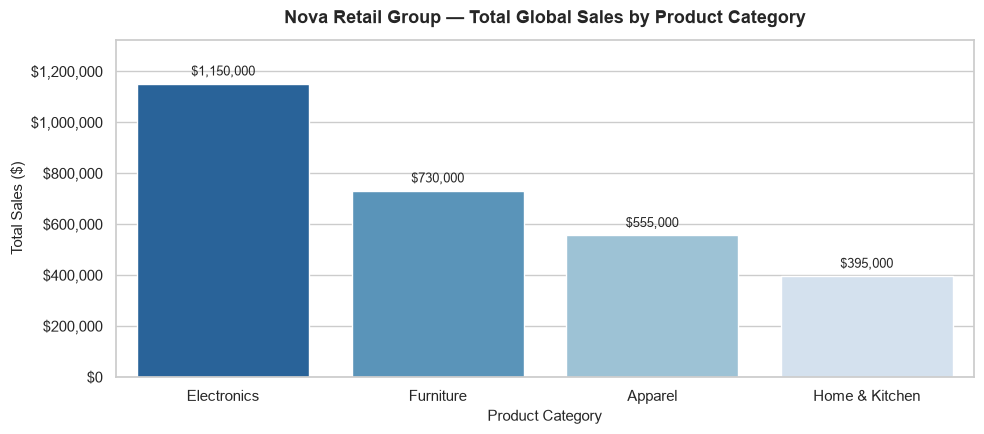

In [6]:
# Aggregate total sales by category
cat_sales = df.groupby("category", as_index=False)["sales"].sum().sort_values("sales", ascending=False)

# Chart 1: Overall Category Sales
plt.figure(figsize=(10, 4.5))
ax1 = sns.barplot(
    data=cat_sales,
    x="category",
    y="sales",
    hue="category",
    palette="Blues_r",
    legend=False
)

plt.title("Nova Retail Group — Total Global Sales by Product Category", fontsize=13, fontweight="bold", pad=12)
plt.xlabel("Product Category", fontsize=11)
plt.ylabel("Total Sales ($)", fontsize=11)
plt.gca().yaxis.set_major_formatter('${x:,.0f}')
plt.ylim(0, cat_sales["sales"].max() * 1.15)

# Add data labels on top of bars
for p in ax1.patches:
    ax1.annotate(f"${p.get_height():,.0f}", 
                 (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='bottom', fontsize=9, xytext=(0, 4),
                 textcoords='offset points')

plt.tight_layout()
plt.show()


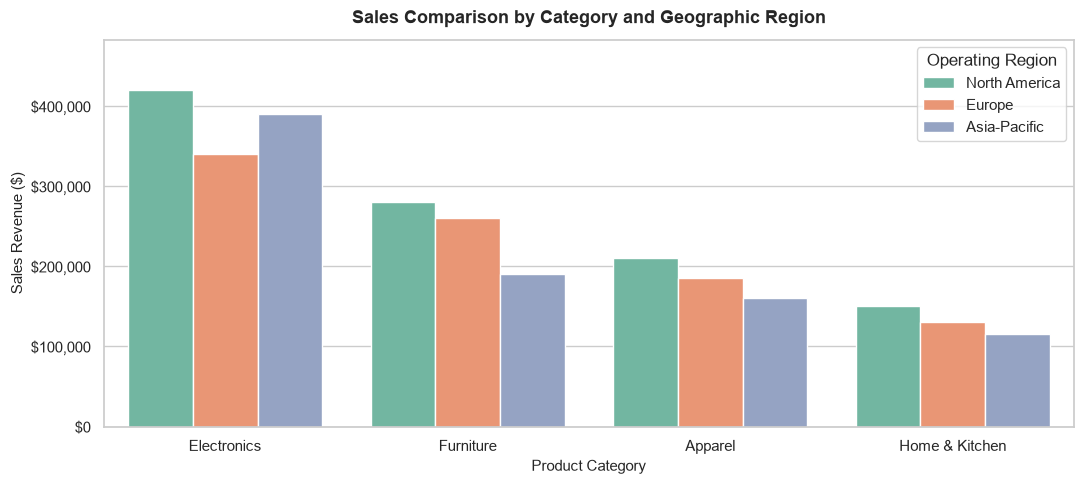

In [7]:
# Chart 2: Grouped Bar Chart (Category + Region)
plt.figure(figsize=(11, 5))
ax2 = sns.barplot(
    data=df,
    x="category",
    y="sales",
    hue="region",
    palette="Set2"
)

plt.title("Sales Comparison by Category and Geographic Region", fontsize=13, fontweight="bold", pad=12)
plt.xlabel("Product Category", fontsize=11)
plt.ylabel("Sales Revenue ($)", fontsize=11)
plt.gca().yaxis.set_major_formatter('${x:,.0f}')
plt.legend(title="Operating Region", loc="upper right")
plt.ylim(0, df["sales"].max() * 1.15)
plt.tight_layout()
plt.show()


## 7. Plotly Express Visualization (Interactive Web Chart)

Plotly Express makes it easy to build interactive grouped bar charts with tooltips and automatic formatting.
- **Hover** over any bar to see sales, profit, and region.
- **Click** on region legend items to toggle regions on/off for focused side-by-side comparisons.


In [8]:
# Interactive Grouped Bar Chart with Plotly Express
fig = px.bar(
    df,
    x="category",
    y="sales",
    color="region",
    barmode="group",
    hover_data=["profit"],
    title="<b>Interactive Sales & Profit Comparison by Category and Region</b>",
    labels={"category": "Product Category", "sales": "Sales Revenue ($)", "region": "Region"},
    text_auto=".2s"
)

# Customize layout aesthetics
fig.update_layout(
    yaxis_title="Sales Revenue ($)",
    yaxis_tickprefix="$",
    template="plotly_white",
    legend_title="Region"
)

fig.show()


## 8. Interpretation

Examining the visual evidence leads to several critical findings:

1. **Volume Dominance (Electronics):**
   - **Electronics** generates the highest sales revenue globally ($1,150,000 across all 3 regions), leading in North America ($420k), Asia-Pacific ($390k), and Europe ($340k).
   - Furniture is the second-largest sales generator ($730,000 total), followed by Apparel ($555,000) and Home & Kitchen ($395,000).

2. **Regional Hierarchy:**
   - **North America** is the strongest market across all four categories, producing the tallest bar in each cluster.
   - **Asia-Pacific** ranks second in Electronics and Furniture, while **Europe** performs strongly in Apparel.

3. **The Hidden Margin Issue (Profitability):**
   - When inspecting the tooltips or profit records, **Furniture in Europe** generated $260,000 in sales but recorded a net **loss of -$14,000**.
   - Conversely, **Apparel** produces less than half the sales volume of Electronics, yet generates an astonishing **$164,000** in total profit.


## 9. Key Insights & Recommended Business Actions

### What Happened?
- Electronics drives bulk top-line revenue, but Apparel is the company's true profit powerhouse.
- European Furniture is actively destroying value due to international freight and delivery overhead.

### Actionable Business Recommendations:
1. **Restructure European Furniture Logistics:**
   - Audit European distribution partners immediately. Renegotiate carrier contracts or shift to localized flat-pack fulfillment to eliminate the -$14,000 loss.
2. **Double Marketing Investment in Apparel:**
   - Because Apparel delivers ~30% net profit margins (over $164k on $555k sales), marketing spend allocated to Apparel delivers significantly higher cash return per dollar spent than Electronics.
3. **Scale Home & Kitchen in Asia-Pacific:**
   - Home & Kitchen exhibits steady profitability in North America; expanding product assortment in Asia-Pacific offers a low-risk growth lever.

---

### Common Analytical Mistake to Avoid:
> **Mistake: Truncating the Baseline (Non-Zero Y-Axis on Bar Charts)**  
> Unlike line charts where the focus is slope over time, **bar charts encode value through the physical length of the bar**. If a bar chart's vertical axis begins at $200,000 instead of $0, a bar representing $250,000 will appear five times taller than a bar representing $210,000, even though the true mathematical difference is only 19%. **Bar charts must always start at zero** to avoid visual deception.


## 10. Practice Exercises

### Exercise 1: Chart Interpretation
Based on the visualizations above, answer:
1. Which region had the lowest sales for the *Home & Kitchen* category?
2. Which category displays the smallest gap between its highest-selling region and its lowest-selling region?
3. If an executive looked only at the total sales chart, what critical financial risk would they completely overlook?


### Exercise 2: Modify Chart Settings
In the code cell below, create a Seaborn grouped bar chart comparing **`profit`** instead of sales across categories and regions:
- Set `x="category"`, `y="profit"`, and `hue="region"`.
- Add a horizontal dashed reference line at `y=0` (`plt.axhline(0, color='red', linestyle='--')`) to visually highlight positive vs negative profit.
- Give the chart an informative title.


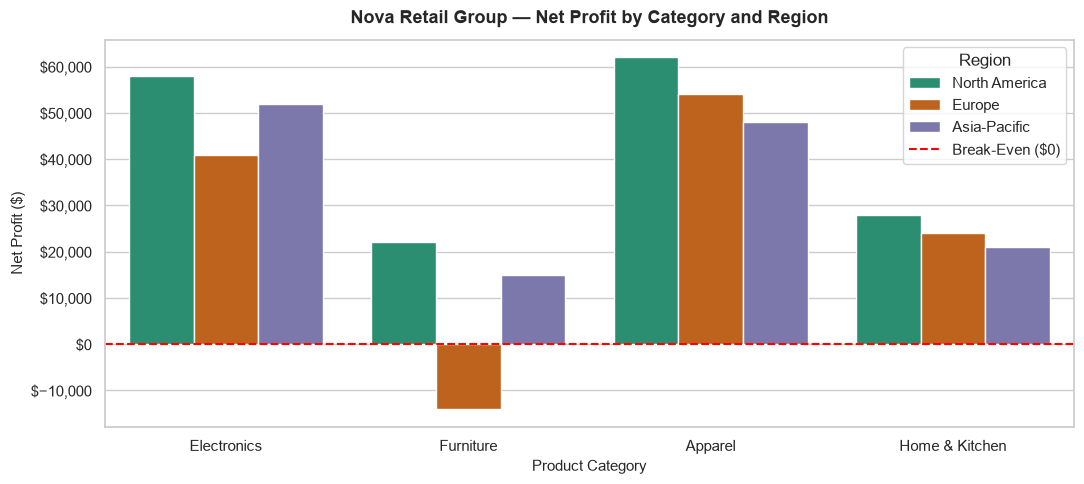

In [9]:
# Exercise 2: Student Code
plt.figure(figsize=(11, 5))

# Create grouped bar chart for profit:
sns.barplot(
    data=df,
    x="category",
    y="profit",
    hue="region",
    palette="Dark2"
)

# Reference line at zero profit
plt.axhline(0, color="red", linestyle="--", linewidth=1.5, label="Break-Even ($0)")

plt.title("Nova Retail Group — Net Profit by Category and Region", fontsize=13, fontweight="bold", pad=12)
plt.xlabel("Product Category", fontsize=11)
plt.ylabel("Net Profit ($)", fontsize=11)
plt.gca().yaxis.set_major_formatter('${x:,.0f}')
plt.legend(title="Region")
plt.tight_layout()
plt.show()


### Exercise 3: Answer a Business Question
Calculate the **Profit Margin (%)** for each category across all regions combined:
$$\text{Profit Margin (\%)} = \left( \frac{\text{Total Profit}}{\text{Total Sales}} \right) \times 100$$
Which category has the highest margin, and which has the lowest?


In [10]:
# Exercise 3: Student Code
# Group by category and compute total sales and profit
margin_df = df.groupby("category", as_index=False)[["sales", "profit"]].sum()
margin_df["margin_pct"] = (margin_df["profit"] / margin_df["sales"]) * 100
margin_df = margin_df.sort_values("margin_pct", ascending=False)

# Display formatted results
for _, row in margin_df.iterrows():
    print(f"{row['category']:<15} | Sales: ${row['sales']:>9,f} | Profit: ${row['profit']:>8,f} | Margin: {row['margin_pct']:>5.1f}%")


Apparel         | Sales: $555,000.000000 | Profit: $164,000.000000 | Margin:  29.5%
Home & Kitchen  | Sales: $395,000.000000 | Profit: $73,000.000000 | Margin:  18.5%
Electronics     | Sales: $1,150,000.000000 | Profit: $151,000.000000 | Margin:  13.1%
Furniture       | Sales: $730,000.000000 | Profit: $23,000.000000 | Margin:   3.2%


## 11. Challenge Activity

**Faceted Comparison Charts:**  
When comparing multiple sub-groups, grouped bars can become visually crowded. A **faceted chart** (small multiples) splits the data into side-by-side subplots for each region.

1. Using `px.bar`, create a faceted bar chart comparing `sales` across `category`, with `facet_col="region"`.
2. Color the bars by `profit` so viewers can assess revenue and profitability simultaneously.
3. Write two business takeaways explaining how faceting improves clarity over a standard grouped bar chart.


In [11]:
# Challenge Activity: Faceted Bar Chart
fig_facet = px.bar(
    df,
    x="category",
    y="sales",
    color="profit",
    facet_col="region",
    color_continuous_scale="RdBu",
    title="<b>Faceted Category Sales by Region (Colored by Profit)</b>",
    labels={"sales": "Sales ($)", "category": "Category", "profit": "Profit ($)"}
)
fig_facet.update_layout(template="plotly_white")
fig_facet.show()


## 12. Key Takeaways

- **When to Use:** Use **bar charts** when comparing discrete nominal or ordinal categories. Bar charts leverage position and length along an aligned scale — the most accurate visual perception channels.
- **Grouped Bars for 2D Comparisons:** Grouped bar charts enable simultaneous evaluation of two categorical dimensions (e.g., category and region).
- **Zero-Baseline Rule:** Bar charts **must always** begin at zero. Bar length represents magnitude; truncating the baseline distorts ratios and misleads audiences.
- **Revenue vs Profit:** High revenue does not guarantee high profitability. Always inspect volume and margin metrics side-by-side when evaluating business performance.
